# Plot the global time series of amoc for a given model and variable

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


## Set parameters

In [2]:
lat_choice = 26.5
lat_string = str(lat_choice).replace('.','p')
min_depth_choice = 300
basin_choice = 'atlantic_arctic_ocean'
ref_year = 1
ref_period = 10

freq = 'yearly'#'yearly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
#varias = ['msftyz'] # 'tas','tos',
models = ['IPSL-CM6-ESMCO2','GFDL-ESM2M','NorESM2-LM','GISSE2.1-G-CC2','UKESM1-2','EC-Earth3-ESM-1']#[]#,
runs = pruns.get_run_list('tipmip_tier1')#[1:]

model_dict = pmods.get_model_dict('all')
run_dict = pruns.get_run_dict()


## Convert time series

In [3]:
def convert_units(varia,da):
    if da.units == 'kg s-1' or da.units == 'kg/s':
        converter = 1/1026 / 10**6
        da_conv = da*converter
        da_conv.attrs["units"] = r'Sv'
    else:    
        da_conv = da
    return da_conv

def get_varia(model):
    if model in ['IPSL-CM6-ESMCO2','GFDL-ESM2M','GISSE2.1-G-CC2','UKESM1-2','EC-Earth3-ESM-1']:
        varia = 'msftyz'
    elif model in ['NorESM2-LM']:
        varia = 'msftmz'
    else:
        raise Exception('Varia not yet chosen for this model.')
    return varia


## Load and plot

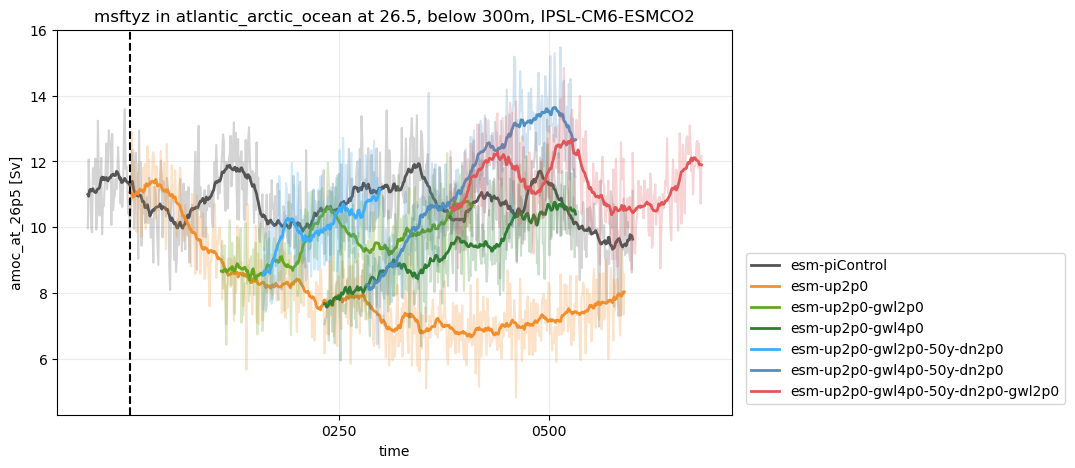

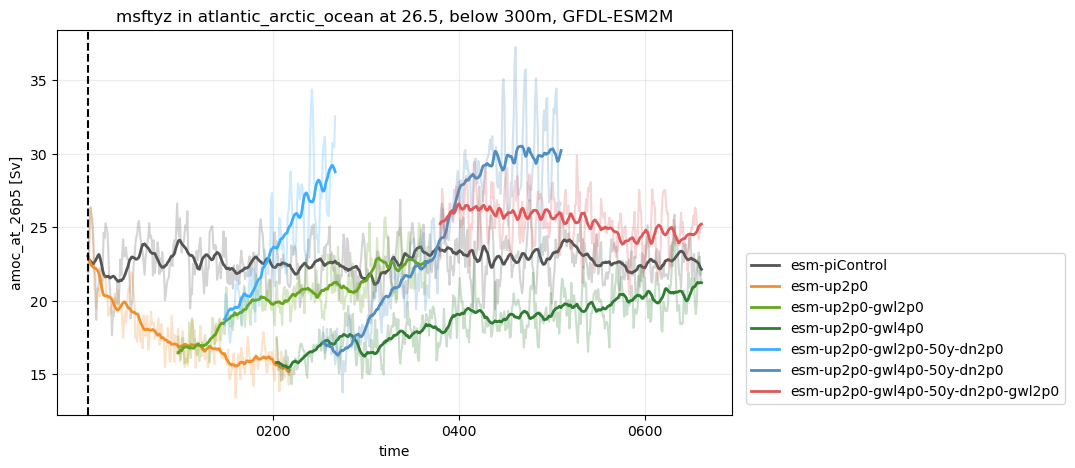

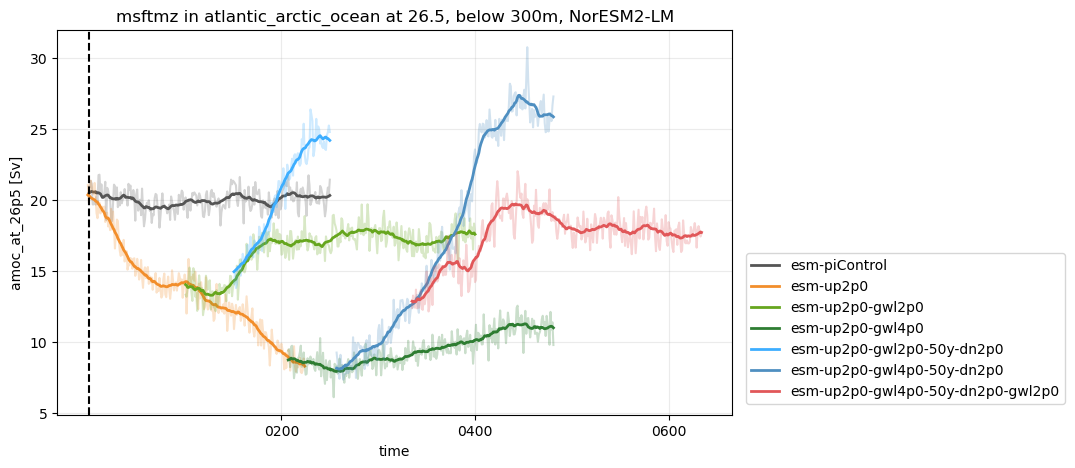

Nothing to plot for msftyz, GISSE2.1-G-CC2, r0i0p0f0, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, yearly, amoc.


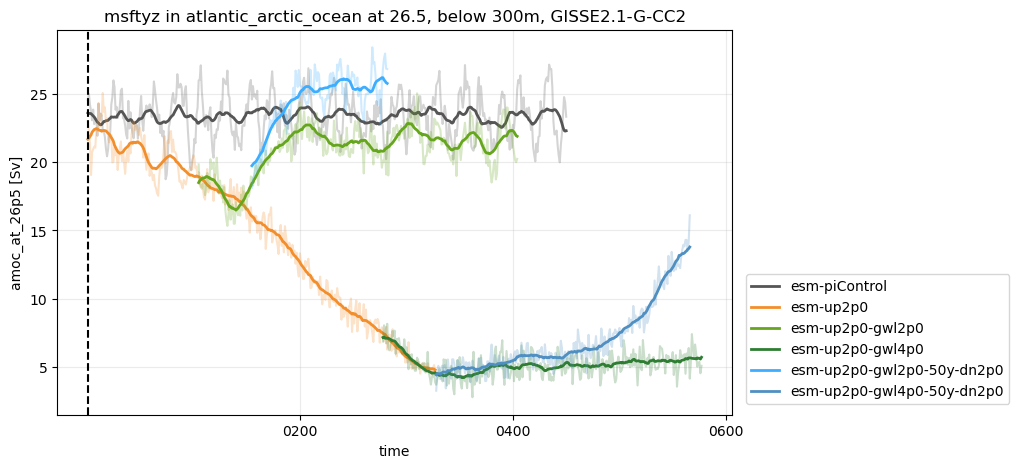

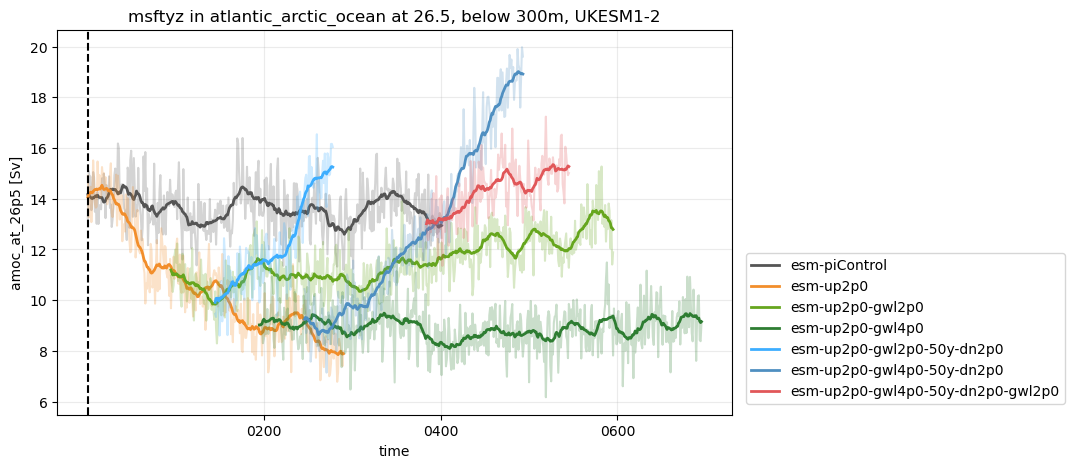

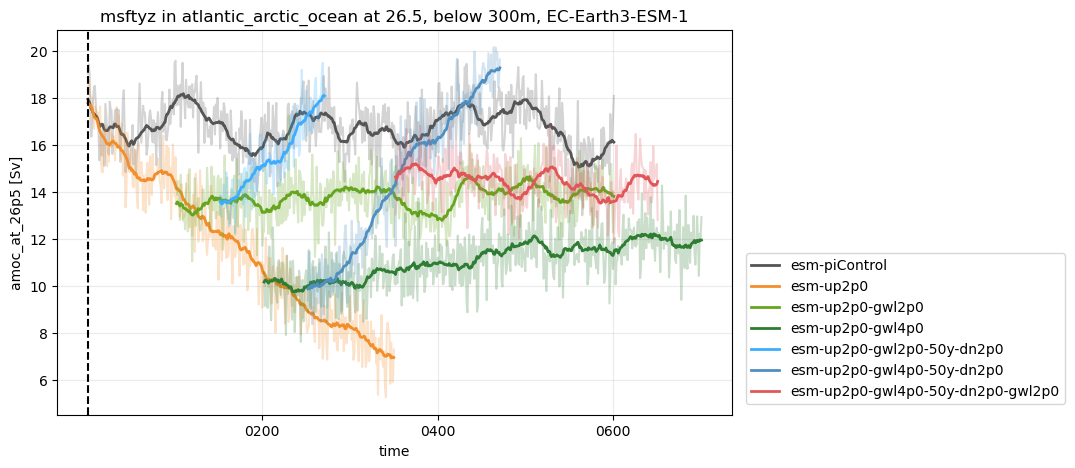

In [4]:
for model in models:
    varia = get_varia(model)
    #stat = get_stat(varia)
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()
    #color = model_dict[model].color_id
    global_stats = dict()
    fig, ax = plt.subplots(figsize=(10,5))
    for run in runs:
        try:
            color = run_dict[run].color_id
            load_dir = f'./../01_postprocessed_data/amoc_time_series/{varia}/{model}/{run}/{member}/{freq}'
            load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{freq}_{basin_choice}_{lat_string}_{min_depth_choice}m.nc'
            global_stat = xr.open_dataset(load_string,use_cftime=True)
            global_stat = global_stat[f"amoc_at_{lat_string}"]
            global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)
            # convert
            global_stat = convert_units(varia,global_stat)

            # put into dictionary
            global_stats[run] = global_stat
            #for key in global_stats.keys():
            #print(f'... plotting {run} ...')
            global_stats[run].plot(alpha=0.25,color=color) # plot the annual data
            global_stats[run].rolling(time=21, center=True,min_periods=1).mean().plot(alpha=1,linewidth=2,color=color,label=run) # plot the 21year running mean
        except:
            print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq}, amoc.')
    ax.set_title(f"{varia} in {basin_choice} at {lat_choice}, below {min_depth_choice}m, {model}")
    ax.grid(alpha=0.25)
    ax.axvline(cftime.DatetimeGregorian(ref_year, 1, 1),color='k',linestyle='--')
    plt.subplots_adjust(right=0.8)
    plt.legend(loc='lower left',bbox_to_anchor=(1.01,0.01))
    plt.show()

## Plot all models together for a given variable (annual means only and a n-year running mean, n=11)

Nothing to plot for msftyz, GISSE2.1-G-CC2, r0i0p0f0, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, yearly.


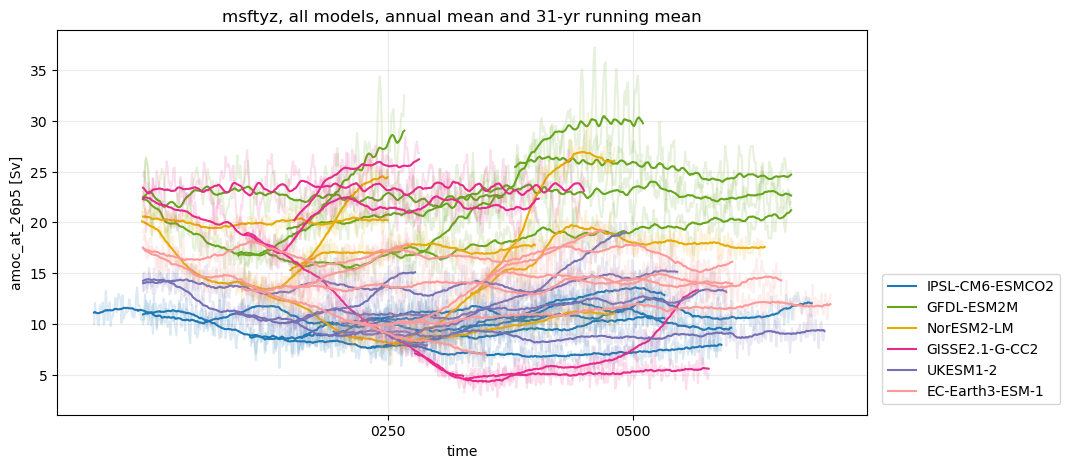

In [5]:
running_mean_years = 31

fig, ax = plt.subplots(figsize=(12,5))
for model in models:
    varia = get_varia(model)
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()
    #color = model_dict[model].color_id
    global_stats = dict()
    for run in runs:
        try:
            color = model_dict[model].color_id#run_dict[run].color_id
            load_dir = f'./../01_postprocessed_data/amoc_time_series/{varia}/{model}/{run}/{member}/{freq}'
            load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{freq}_{basin_choice}_{lat_string}_{min_depth_choice}m.nc'
            global_stat = xr.open_dataset(load_string,use_cftime=True)
            global_stat = global_stat[f"amoc_at_{lat_string}"]
            global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)

            # convert
            global_stat = convert_units(varia,global_stat)
    
            # put into dictionary
            global_stats[run] = global_stat
    
            annual_means = global_stat.resample(time="1YS").mean()
            annual_means.plot(alpha=.15,color=color)#,label=run)
    
            if run == 'esm-up2p0':
                label=model
            else:
                label=''
            annual_means.rolling(time=running_mean_years,center=True,min_periods=1).mean().plot(alpha=1,color=color,label=label)#,label=run)
        except:
            print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq}.')
            
ax.set_title(f'{varia}, all models, annual mean and {running_mean_years}-yr running mean')
ax.grid(alpha=0.25)
plt.subplots_adjust(right=0.8)
plt.legend(loc='lower left',bbox_to_anchor=(1.01,0.01))
plt.show()

## Now plot the change rather than the absolute values

Nothing to plot for msftyz, GISSE2.1-G-CC2, r0i0p0f0, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, yearly.


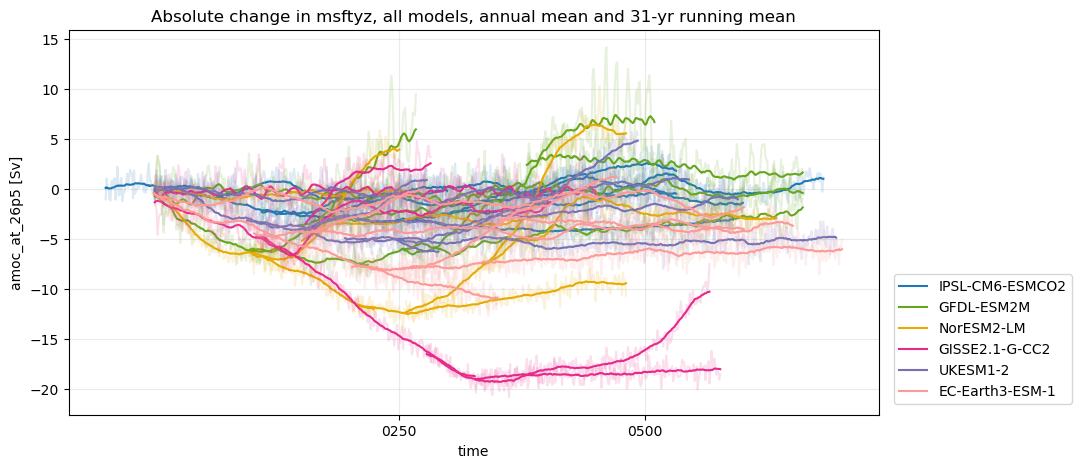

In [6]:
def get_reference_value(varia,model):
    #freq_input = get_freq_input(model)
    #stat = get_stat(varia)
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()
    run = 'esm-piControl'
    load_dir = f'./../01_postprocessed_data/amoc_time_series/{varia}/{model}/{run}/{member}/{freq}'
    load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{freq}_{basin_choice}_{lat_string}_{min_depth_choice}m.nc'
    global_stat = xr.open_dataset(load_string,use_cftime=True)
    global_stat = global_stat[f"amoc_at_{lat_string}"]
    global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)
    reference_value = global_stat.sel(time=slice(f'{ref_year:04d}-01-01',f'{(ref_year+ref_period):04d}-01-01')).mean('time').values
    return reference_value

running_mean_years = 31

fig, ax = plt.subplots(figsize=(12,5))
for model in models:
    varia = get_varia(model)
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()
    #color = model_dict[model].color_id
    reference_value = get_reference_value(varia,model)
    global_stats = dict()
    for run in runs:
        try:
            color = model_dict[model].color_id#run_dict[run].color_id
            load_dir = f'./../01_postprocessed_data/amoc_time_series/{varia}/{model}/{run}/{member}/{freq}'
            load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{freq}_{basin_choice}_{lat_string}_{min_depth_choice}m.nc'
            global_stat = xr.open_dataset(load_string,use_cftime=True)
            global_stat = global_stat[f"amoc_at_{lat_string}"]
            units = global_stat.units
            global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)

            #print(global_stat)
            #print(reference_value)
            global_stat = global_stat - reference_value
            #print(global_stat.units)
            global_stat.attrs['units'] = units
    
            # convert
            global_stat = convert_units(varia,global_stat)
    
            # put into dictionary
            global_stats[run] = global_stat
            
            #annual_means = global_stat.resample(time="1YS").mean()
            global_stat.plot(alpha=.15,color=color)#,label=run)
    
            if run == 'esm-up2p0':
                label=model
            else:
                label=''
            global_stat.rolling(time=running_mean_years,center=True,min_periods=1).mean().plot(alpha=1,color=color,label=label)#,label=run)
        except:
            print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq}.')
            
ax.set_title(f'Absolute change in {varia}, all models, annual mean and {running_mean_years}-yr running mean')
ax.grid(alpha=0.25)
plt.subplots_adjust(right=0.8)
plt.legend(loc='lower left',bbox_to_anchor=(1.01,0.01))
plt.show()

## Now plot the relative change rather than the absolute change

Nothing to plot for msftyz, GISSE2.1-G-CC2, r0i0p0f0, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, yearly.


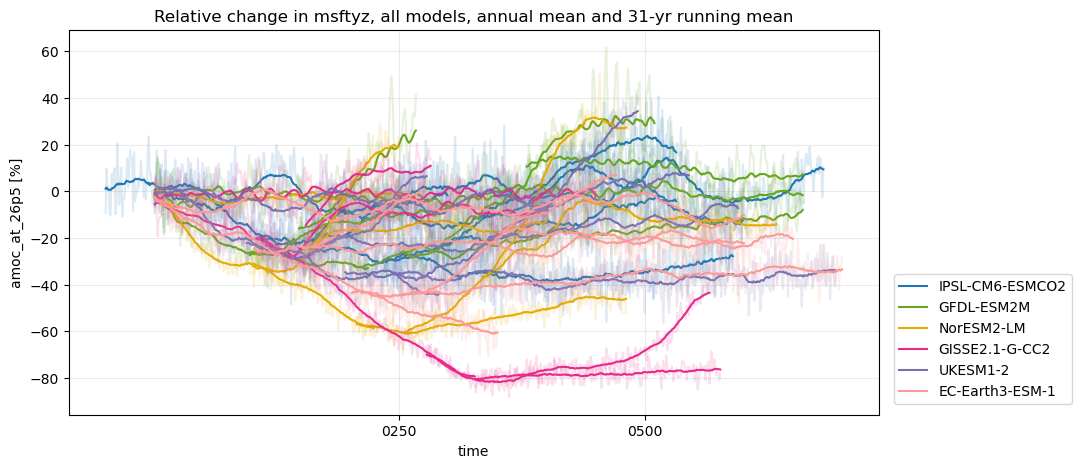

In [7]:
def get_reference_value(varia,model):
    #freq_input = get_freq_input(model)
    #stat = get_stat(varia)
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()
    run = 'esm-piControl'
    load_dir = f'./../01_postprocessed_data/amoc_time_series/{varia}/{model}/{run}/{member}/{freq}'
    load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{freq}_{basin_choice}_{lat_string}_{min_depth_choice}m.nc'
    global_stat = xr.open_dataset(load_string,use_cftime=True)
    global_stat = global_stat[f"amoc_at_{lat_string}"]
    global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)
    reference_value = global_stat.sel(time=slice(f'{ref_year:04d}-01-01',f'{(ref_year+ref_period):04d}-01-01')).mean('time').values
    return reference_value

running_mean_years = 31

fig, ax = plt.subplots(figsize=(12,5))
for model in models:
    varia = get_varia(model)
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()
    #color = model_dict[model].color_id
    reference_value = get_reference_value(varia,model)
    global_stats = dict()
    for run in runs:
        try:
            color = model_dict[model].color_id#
            load_dir = f'./../01_postprocessed_data/amoc_time_series/{varia}/{model}/{run}/{member}/{freq}'
            load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{freq}_{basin_choice}_{lat_string}_{min_depth_choice}m.nc'
            global_stat = xr.open_dataset(load_string,use_cftime=True)
            global_stat = global_stat[f"amoc_at_{lat_string}"]
            units = global_stat.units
            global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)
    
            global_stat = (global_stat - reference_value)/reference_value*100 # in %
            global_stat.attrs['units'] = '%' #units
    
            # convert
            global_stat = convert_units(varia,global_stat)
    
            # put into dictionary
            global_stats[run] = global_stat
            
            #annual_means = global_stat.resample(time="1YS").mean()
            global_stat.plot(alpha=.15,color=color)#,label=run)
    
            if run == 'esm-up2p0':
                label= model
            else:
                label=''
            global_stat.rolling(time=running_mean_years,center=True,min_periods=1).mean().plot(alpha=1,color=color,label=label)#,label=run)
        except:
            print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq}.')
            
ax.set_title(f'Relative change in {varia}, all models, annual mean and {running_mean_years}-yr running mean')
ax.grid(alpha=0.25)
plt.subplots_adjust(right=0.8)
plt.legend(loc='lower left',bbox_to_anchor=(1.01,0.01))
plt.show()



Nothing to plot for msftyz, GISSE2.1-G-CC2, r0i0p0f0, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, yearly.


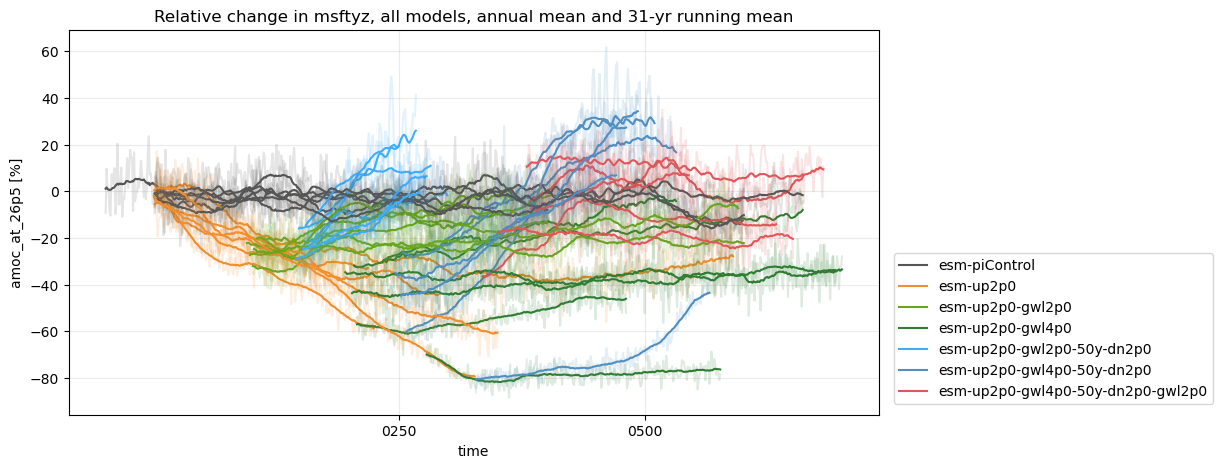

In [8]:
def get_reference_value(varia,model):
    #freq_input = get_freq_input(model)
    #stat = get_stat(varia)
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()
    run = 'esm-piControl'
    load_dir = f'./../01_postprocessed_data/amoc_time_series/{varia}/{model}/{run}/{member}/{freq}'
    load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{freq}_{basin_choice}_{lat_string}_{min_depth_choice}m.nc'
    global_stat = xr.open_dataset(load_string,use_cftime=True)
    global_stat = global_stat[f"amoc_at_{lat_string}"]
    global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)
    reference_value = global_stat.sel(time=slice(f'{ref_year:04d}-01-01',f'{(ref_year+ref_period):04d}-01-01')).mean('time').values
    return reference_value

running_mean_years = 31

fig, ax = plt.subplots(figsize=(12,5))
for model in models:
    varia = get_varia(model)
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()
    #color = model_dict[model].color_id
    reference_value = get_reference_value(varia,model)
    global_stats = dict()
    for run in runs:
        try:
            color = run_dict[run].color_id # model_dict[model].color_id#
            color2 = model_dict[model].color_id#

            load_dir = f'./../01_postprocessed_data/amoc_time_series/{varia}/{model}/{run}/{member}/{freq}'
            load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{freq}_{basin_choice}_{lat_string}_{min_depth_choice}m.nc'
            global_stat = xr.open_dataset(load_string,use_cftime=True)
            global_stat = global_stat[f"amoc_at_{lat_string}"]
            units = global_stat.units
            global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)
            global_stat = (global_stat - reference_value)/reference_value*100 # in %
            global_stat.attrs['units'] = '%' #units
    
            # convert
            global_stat = convert_units(varia,global_stat)
    
            # put into dictionary
            global_stats[run] = global_stat
            
            #annual_means = global_stat.resample(time="1YS").mean()
            global_stat.plot(alpha=.15,color=color)#,label=run)
    
            if model == 'IPSL-CM6-ESMCO2':#'esm-up2p0':
                label=run # model
            else:
                label=''
            #global_stat.rolling(time=running_mean_years,center=True,min_periods=1).mean().plot(alpha=1,color=color2,linewidth=2.5)#,label=run)
            global_stat.rolling(time=running_mean_years,center=True,min_periods=1).mean().plot(alpha=1,color=color,label=label)#,linewidth=2)#,label=run)

        except:
            print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq}.')
            
ax.set_title(f'Relative change in {varia}, all models, annual mean and {running_mean_years}-yr running mean')
ax.grid(alpha=0.25)
plt.subplots_adjust(right=0.8)
plt.legend(loc='lower left',bbox_to_anchor=(1.01,0.01))
plt.show()